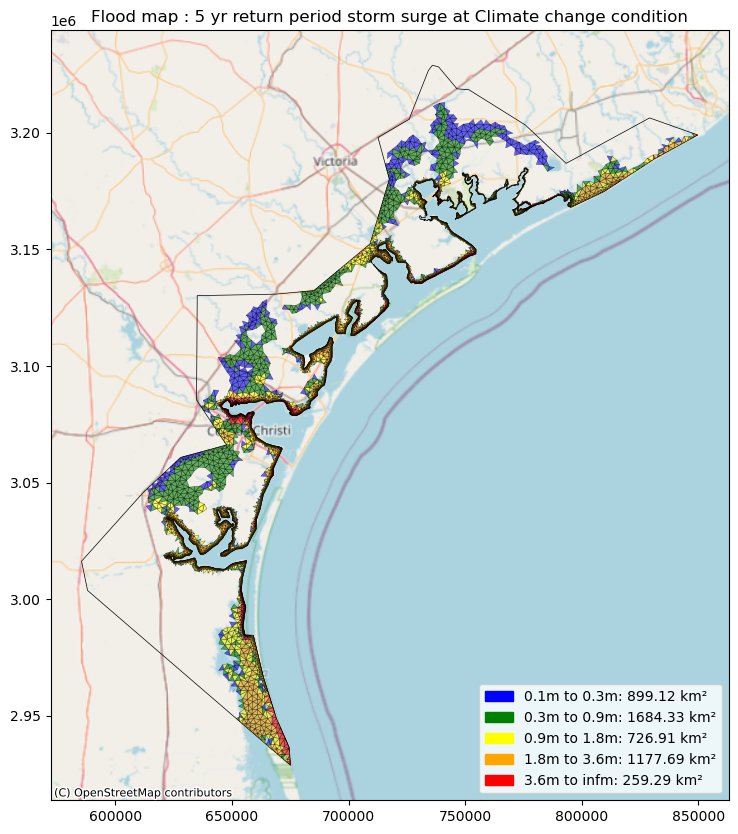

Depth range 0.1m to 0.3m: 899.12 square kilometers
Depth range 0.3m to 0.9m: 1684.33 square kilometers
Depth range 0.9m to 1.8m: 726.91 square kilometers
Depth range 1.8m to 3.6m: 1177.69 square kilometers
Depth range 3.6m to infm: 259.29 square kilometers


In [2]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # UTM Zone 14N
    )
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Plotting with Basemap
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:  # Plot only if there are polygons in the range
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add basemap
ctx.add_basemap(ax, crs=land_boundary.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood map : 5 yr return period storm surge at Climate change condition')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


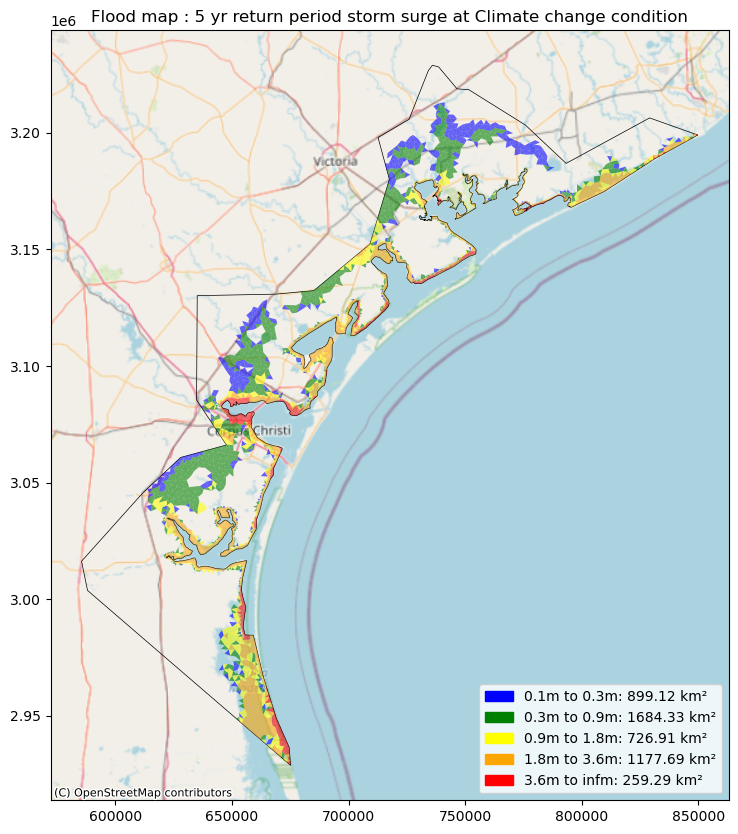

Depth range 0.1m to 0.3m: 899.12 square kilometers
Depth range 0.3m to 0.9m: 1684.33 square kilometers
Depth range 0.9m to 1.8m: 726.91 square kilometers
Depth range 1.8m to 3.6m: 1177.69 square kilometers
Depth range 3.6m to infm: 259.29 square kilometers


In [5]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # UTM Zone 14N
    )
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Plotting with Basemap
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color and set edgecolor='none' to remove mesh visibility
for polygons, color in zip(flooded_polygons_by_range, colors):
    if not polygons.empty:  # Plot only if there are polygons in the range
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')  # edgecolor='none' hides the mesh lines

# Add basemap
ctx.add_basemap(ax, crs=land_boundary.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood map : 5 yr return period storm surge at Climate change condition')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


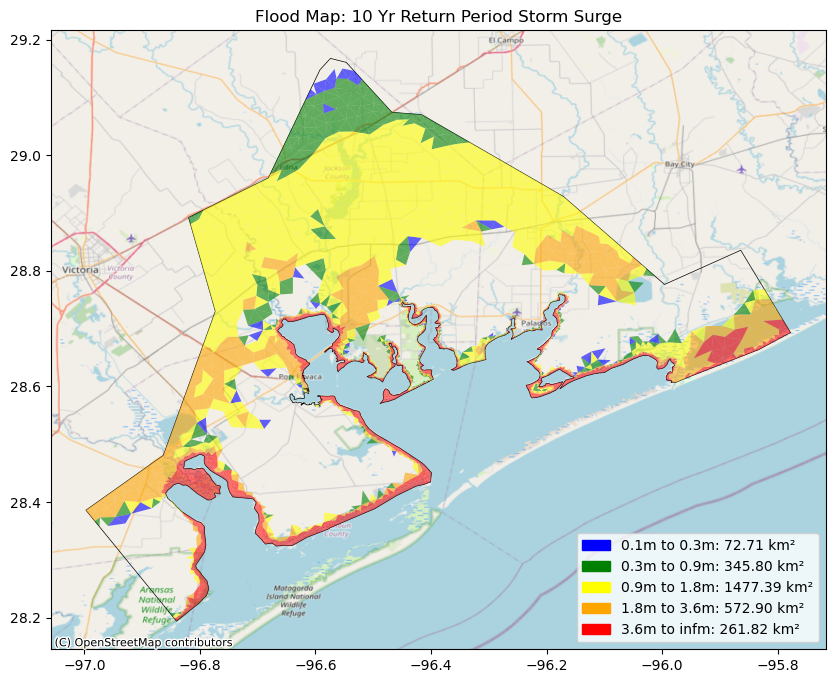

Depth range 0.1m to 0.3m: 72.71 square kilometers
Depth range 0.3m to 0.9m: 345.80 square kilometers
Depth range 0.9m to 1.8m: 1477.39 square kilometers
Depth range 1.8m to 3.6m: 572.90 square kilometers
Depth range 3.6m to infm: 261.82 square kilometers


In [8]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC_Stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\Project_Proposal\study_area_land_Part.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

# Process each depth range and create polygons
for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")  # UTM Zone 14N
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Reproject everything to Lat-Long (WGS 84, EPSG:4326)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Plotting with Basemap in Lat-Long
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add a Lat-Long basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood Map: 10 Yr Return Period Storm Surge')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")


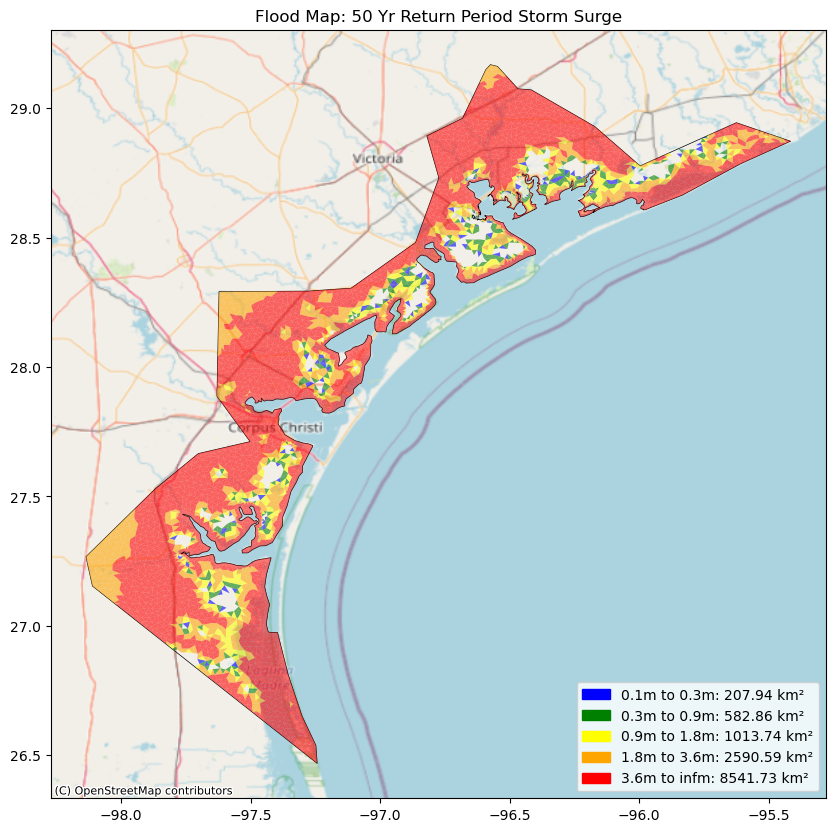

Depth range 0.1m to 0.3m: 207.94 square kilometers
Depth range 0.3m to 0.9m: 582.86 square kilometers
Depth range 0.9m to 1.8m: 1013.74 square kilometers
Depth range 1.8m to 3.6m: 2590.59 square kilometers
Depth range 3.6m to infm: 8541.73 square kilometers


In [1]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\50-yr return period storm CC.m21fm - Result Files\50-yr_CC_coupled_stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

# Process each depth range and create polygons
for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")  # UTM Zone 14N
    
    # Clip the polygons with the shapefile boundary
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Reproject everything to Lat-Long (WGS 84, EPSG:4326)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Plotting with Basemap in Lat-Long
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot each range with a different color
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add a Lat-Long basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flood Map: 50 Yr Return Period Storm Surge')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")
